# 土木のためのPython入門⑦ GeoPandas入門編

**tags:** Python / 初心者 / geopandas / GIS / 土木工学  
**author:** skyblueao77

> **この記事の対象者**
> - Pythonをこれから土木工学、都市工学に活用したい方
> - Pythonの基本文法を理解している方
> - pandas、NumPy、Matplotlibを学んだ方
> - GISや地理空間データをPythonで扱ってみたい方

> **注意**
> 本記事は筆者個人の学習記録です。内容は公式ドキュメント等でも確認し、実務上の設計・安全性の判断には関係法令、設計基準、専門家による確認等を行ってください。

[これまでの記事一覧](https://qiita.com/skyblueao77/items/ea31e9890f6368b25e19)  
[GitHubリポジトリ](https://github.com/skyblueao77/civil-engineering-python)

## はじめに
これまでの記事では、Pythonの基本文法からpandas、Matplotlib、NumPy・SciPyを学んできました。今回からは、土木工学で重要な「位置情報を持つデータ」をPythonで扱います。

道路、河川、行政区域、土地利用、標高、浸水区域などの地理的な位置と結びついたデータをPythonで扱う代表的なライブラリが **GeoPandas** です。


## 1. GeoPandasとは
[GeoPandas](https://geopandas.org/) は、Pythonで地理空間データを扱うためのライブラリです。pandasの `DataFrame` を拡張した `GeoDataFrame` を中心に、属性情報と地理情報を一緒に扱えます。

通常のpandas:
```text
地点名     人口
A地区      12000
B地区       8500
C地区      15600
```

GeoPandas:
```text
地区名     人口      geometry
A地区      12000     Polygon(...)
B地区       8500     Polygon(...)
C地区      15600     Polygon(...)
```

> **pandas + 地理情報 = GeoPandas**


## 2. インストール
uvを利用している場合:
```bash
uv add geopandas
```

GitHubリポジトリから環境を再現する場合:
```bash
git clone https://github.com/skyblueao77/civil-engineering-python.git
cd civil-engineering-python
uv sync
```

環境によって追加ライブラリが必要な場合があります。詳細はGeoPandas公式ドキュメントを確認してください。


In [ ]:
import geopandas as gpd


GeoPandasはShapely、pyproj、pyogrioなどと連携します。近年はShapefileに加え、1ファイルで扱いやすいGeoPackage（.gpkg）も広く利用されています。

## 3. GeoDataFrame
通常のpandasでは `DataFrame` を使います。


In [1]:
import pandas as pd

df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "population": [12000, 8500, 15600]
})

df


,name,population
0,A,12000
1,B,8500
2,C,15600


GeoPandasでは、これに地理情報を持たせることができます。


In [2]:
import geopandas as gpd
from shapely.geometry import Point

gdf = gpd.GeoDataFrame(
    {"name": ["A", "B", "C"], "population": [12000, 8500, 15600]},
    geometry=[Point(135.0, 34.7), Point(135.1, 34.7), Point(135.0, 34.8)],
    crs="EPSG:4326",
)

gdf


,name,population,geometry
0,A,12000,POINT (135 34.7)
1,B,8500,POINT (135.1 34.7)
2,C,15600,POINT (135 34.8)


> **補足:** EPSG:4326はWGS 84です。`to_crs()` は必要に応じて座標変換を行います。測量成果や高精度GNSSデータでは、元データの測地系、基準時点、標高基準も確認してください。

> Shapely の `Point(x, y)` は「x座標, y座標」です。EPSG:4326では通常 `(経度, 緯度)` と考えます。


<Axes: >

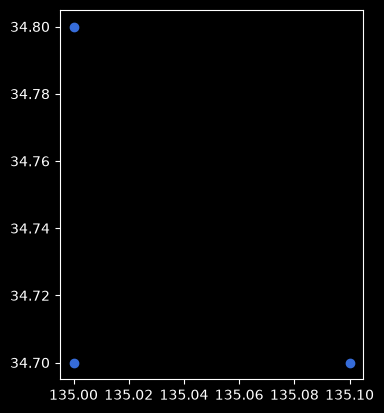

In [3]:
gdf.plot()


`geometry` 列には地理的位置が入ります。
- `Point`: 点（観測地点、駅、橋梁位置）
- `LineString`: 線（道路、河川、鉄道路線）
- `Polygon`: 面（行政区域、敷地、流域）

## 4. GeoSeries
`GeoDataFrame` の `geometry` 列は `GeoSeries` として扱われます。


In [4]:
gdf.geometry


0      POINT (135 34.7)
1    POINT (135.1 34.7)
2      POINT (135 34.8)
Name: geometry, dtype: geometry

In [5]:
gdf.geometry.x


0    135.0
1    135.1
2    135.0
dtype: float64

In [6]:
gdf.geometry.y


0    34.7
1    34.7
2    34.8
dtype: float64

## 5. 実際の地理空間データを読み込む
GeoJSON、Shapefile、GeoPackage、FlatGeobufなどを扱えます。以下はファイルが用意されている場合に実行してください。


In [7]:
# gdf = gpd.read_file("data/sample.geojson")
# gdf.head()


In [ ]:
# gdf.info()


In [ ]:
# gdf.geometry


## 6. 座標参照系（CRS）と平面直角座標系への変換
CRSは `.crs` で確認できます。EPSG:4326はWGS 84で、座標単位は度です。


In [ ]:
print(gdf.crs)


### GIS初心者が陥りやすい落とし穴
経緯度データのまま `.distance()`、`.area`、`.buffer()` を行うと、メートル単位の計算にはなりません。

```python
# ❌ EPSG:4326のまま100 mのつもりでバッファ
buffer = gdf.geometry.buffer(100)
```

GeoPandasの基本的な幾何演算は二次元平面上で行われるため、目的と地域に応じた投影座標系を使用します。

### 土木・測量で欠かせない「平面直角座標系」
日本では全国を19の地域に分けた平面直角座標系があります。例:

| 主な適用地域 | 系 | EPSG |
|---|---|---|
| 兵庫県・鳥取県・岡山県 | 第5系 | `EPSG:6673` |
| 京都府・大阪府・福井県・滋賀県・三重県・奈良県・和歌山県 | 第6系 | `EPSG:6674` |
| 石川県・富山県・岐阜県・愛知県 | 第7系 | `EPSG:6675` |
| 東京都の一部を除く関東等 | 第9系 | `EPSG:6677` |

JGD2000では異なるEPSGコードが割り当てられています。また、2026年4月のEPSGデータセット更新により名称表示が変わる場合があります。

兵庫県のデータを第5系へ変換する例:


In [8]:
gdf_projected = gdf.to_crs("EPSG:6673")


## 7. 地理空間データを可視化する
`plot()` で簡単に描画でき、Matplotlibとも組み合わせられます。


<Axes: >

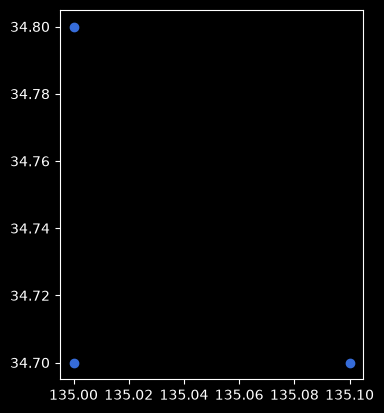

In [9]:
gdf.plot()


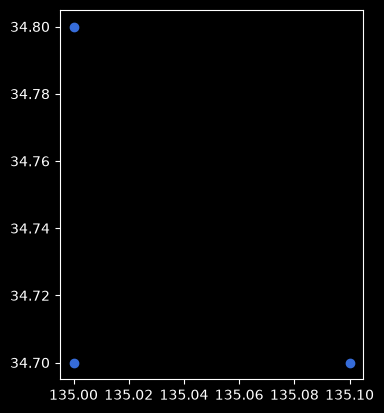

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
gdf.plot(ax=ax)
plt.show()


## 8. 属性情報によって色を変える


<Axes: >

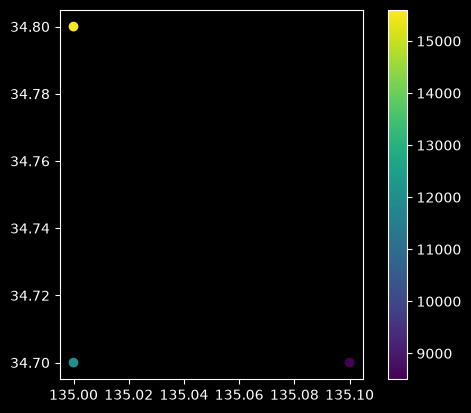

In [11]:
gdf.plot(
    column="population",
    legend=True,
)


人口・世帯数、降水量、浸水深、土地利用、交通量、標高、災害リスクなどを地図上で表現できます。

## 9. バッファを作成する
距離を扱う場合は、適切なメートル単位の投影座標系へ変換してから処理します。


In [12]:
gdf_projected = gdf.to_crs("EPSG:6673")
buffer = gdf_projected.geometry.buffer(100)
buffer


0    POLYGON ((61174.445 -144014.415, 61173.963 -14...
1    POLYGON ((70335.793 -143949.177, 70335.311 -14...
2    POLYGON ((61100.872 -132921.659, 61100.39 -132...
dtype: geometry

## 10. クリップ
特定の区域内だけを抽出する例です。以下は `roads` と `area` を読み込んだ後に実行します。


In [ ]:
# print(roads.crs)
# print(area.crs)
# area = area.to_crs(roads.crs)
# result = gpd.clip(roads, area)


## 11. 空間結合
位置関係を利用した結合には `sjoin()` が使えます。以下は `points` と `polygons` を用意した後に実行します。


In [ ]:
# polygons = polygons.to_crs(points.crs)
# result = gpd.sjoin(points, polygons, predicate="within")


「この観測地点はどの行政区域に入っているか？」のような処理ができます。境界上の点を含めたい場合には、目的に応じて `intersects` や `covered_by` なども検討します。利用可能な述語は `gdf.sindex.valid_query_predicates` で確認できます。

## 12. 土木工学での利用例とオープンデータ
- **観測地点の領域集計**: 観測地点と行政区域を空間結合し、区域ごとに集計・可視化
- **施設の影響範囲抽出**: 道路ネットワークや避難所周辺にバッファを作成し、対象施設数を抽出

利用例となる公的データ:
- **国土数値情報（国土交通省）**: 行政区域、河川、道路、都市計画、浸水想定区域など
- **基盤地図情報（国土地理院）**: 建築物外形線、標高、道路縁など
- **e-Stat（総務省統計局）**: 国勢調査の小地域境域・人口統計

## 13. GeoPandasだけですべてのGIS処理を行うわけではない
- **Shapely**: ジオメトリ処理
- **pyproj**: 座標変換
- **pyogrio**: 高速な地理空間データ入出力
- **rasterio**: 標高や衛星写真などのラスターデータ
- **NetworkX**: 道路網などのネットワーク分析

GUIでは **QGIS** も強力です。GeoPandasは、Pythonから地理空間データを自動処理・分析するためのライブラリと捉えるとよいでしょう。

## 14. pandasとの違い
| | pandas | GeoPandas |
|---|---|---|
| 基本データ構造 | DataFrame | GeoDataFrame |
| 表データ | ○ | ○ |
| 地理情報 | × | ○ |
| Point / LineString / Polygon | × | ○ |
| 空間結合 | × | ○ |
| GISデータ | 基本的に対象外 | ○ |
| Matplotlibとの連携 | ○ | ○ |

## 15. GeoPandasを使う上での注意点
1. **CRSを確認・明記する**: `gdf.crs` で確認し、不明なCRSを座標値だけから推測して `set_crs()` しない。
2. **距離・面積の単位に注意する**: 適切な投影座標系へ変換する。
3. **`set_crs()` と `to_crs()` を混同しない**: 前者はCRSの割当、後者は座標数値の変換。
4. **データ品質に注意する**: 欠損、ジオメトリの問題、座標精度などを確認し、結果の妥当性を土木的観点から検証する。

## 16. これまでのライブラリとの連携
```text
気象・観測データ
    ↓
pandasで読み込み・整形
    ↓
GeoPandasで観測地点の位置情報と結合
    ↓
NumPy / SciPyで数値計算・補間処理
    ↓
Matplotlib / GeoPandasで地図上に可視化
```

## まとめ
- **GeoPandas** はPythonで地理空間データを扱うためのライブラリ
- `GeoDataFrame` で属性情報と位置情報を一緒に扱える
- 距離・面積・バッファでは適切な投影座標系への変換が重要
- `plot()`、`sjoin()`、`buffer()` などでGISの基本処理を自動化できる
- 国土数値情報などのオープンデータと親和性が高い

## 参考
- [GeoPandas Documentation](https://geopandas.org/)
- [GeoPandas User Guide](https://geopandas.org/en/stable/docs/user_guide.html)
- [pandas Documentation](https://pandas.pydata.org/docs/)
- [Shapely Documentation](https://shapely.readthedocs.io/)
- [pyproj Documentation](https://pyproj4.github.io/pyproj/)
